# 4. Momentum + ML value long/short (S&P 500 universe)

Adds a fifth portfolio to the comparison from notebook **02**: a **dollar-neutral long/short book** driven by a
composite of

* **Momentum** – 12-month trailing return skipping the latest month (`MomentumFactor(252, 21)`), and
* **ML value** – the forward return predicted by tree-ensemble regressors trained on the 18 fundamental ratios
  (`MLReturnFactor`), refreshed each quarter as new filings become available.

Each month the composite is recomputed, the top decile is bought and the bottom decile sold, equal-weighted.
Single-factor books are run alongside so the contribution of each signal is visible.

Data: prices and portfolios from notebook **01**, fundamentals from notebook **03**. No LSEG session is needed here.

### No look-ahead, by construction
* Fundamentals are served **point-in-time** (`StaticFundamentalsProvider`) with a publication lag
  (`AVAILABILITY_LAG_DAYS`), and the model is trained on a **time-based split** (`time_based_split`).
* Weights derived from a signal that uses the close of day *t* only earn returns from *t+1*
  (`run_backtest(..., shift_weights=1)`).
* The universe on each date is restricted to that date's **index members** (`membership` mask), so leavers are not
  traded after they left and joiners not before they joined.

## 4.1 Parameters

In [1]:
START_DATE, END_DATE = "2020-01-01", "2026-08-31"
LOOKBACK_START = "2019-01-01"       # extra price history so 12-1 momentum exists on day one
UNIVERSE = "SP500"                  # composite universe (point-in-time index members)
BASE_PORTFOLIOS = ["SPY", "SP500", "MAG8", "GSPC"]

MOMENTUM_LOOKBACK, MOMENTUM_SKIP = 252, 21
FORWARD_MONTHS = 3                  # label horizon for the ML model (one quarter, matching the fundamental refresh)
MODELLING_END = "2026-12-31"        # labels may extend past the strategy window if prices exist
TEST_SIZE, EMBARGO_MONTHS = 0.2, FORWARD_MONTHS
AVAILABILITY_LAG_DAYS = 45          # fiscal period end -> statements public. 0 reproduces the previous behaviour.
SOURCE_VENDOR = "refinitiv"

REBALANCE = "M"                     # composite refreshed on the first trading day of each month
QUANTILE = 0.10                     # top / bottom decile
COST_BPS = 10                       # one-way cost per unit of turnover
FACTOR_WEIGHTS = {"momentum": 0.5, "ml_value": 0.5}

## 4.2 Connections and the four base portfolios

In [2]:
import sys
import os

import pandas as pd

# Get the current notebook's directory and go up to parent
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print(f"Current directory: {current_dir}")
print(f"Added to path: {parent_dir}")
data_eng_path = os.path.join(parent_dir, 'data_engineering')
files_path = os.path.join(parent_dir, 'toolkit\\files')
print(f"Data engineering folder exists: {os.path.exists(data_eng_path)}")
print(f"Files folder exists: {os.path.exists(files_path)}")

Current directory: c:\SourceCode\InvestmentManagement\toolkit\notebooks
Added to path: c:\SourceCode\InvestmentManagement
Data engineering folder exists: True
Files folder exists: True


In [3]:
import logging
import tempfile

import numpy as np
import pandas as pd
from IPython.display import display

from analytics.backtest import (
    forward_returns, ic_summary, information_coefficient, prices_to_returns, quantile_returns, reconstruction_backtest, run_backtest,
)
from analytics.data_quality import describe_panel, neutralize_single_day_glitches
from analytics.factors import CompositeFactor, MLReturnFactor, MomentumFactor
from analytics.factors import ml_training
from analytics.performance.plots import plot_cumulative_returns, plot_drawdowns
from analytics.portfolio import calculate_portfolio_constituent_returns, calculate_portfolio_constituent_weights, quantile_weights, rebalance_dates
from data_engineering.database import database
from data_engineering.fundamentals import StaticFundamentalsProvider
from data_engineering.loaders import check_point_in_time
from data_engineering.loaders.portfolios import portfolio_member_ids, portfolio_members_on

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")
pd.set_option("display.width", 160)
engine, connection, conn_str, session = database.get_db_connection()

existing = database.read_portfolio(session, engine, BASE_PORTFOLIOS)
missing = set(BASE_PORTFOLIOS) - set(existing["portfolio_short_name"])
assert not missing, f"run notebook 01 first - missing portfolios: {missing}"

market_data = database.get_portfolio_market_data(session, engine, START_DATE, END_DATE, BASE_PORTFOLIOS)
base_returns = calculate_portfolio_constituent_returns(market_data, "adj_close")["returns"]
base_weights = calculate_portfolio_constituent_weights(market_data, "adj_close", "market_weighted", portfolio_specific_weights={"MAG8": "equal_weighted"}, max_weight=0.10)
base = reconstruction_backtest(base_returns, base_weights)
display(base.summary(benchmark="GSPC").round(4))

Database connection successful.


,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,beta,correlation,tracking_error
GSPC,1.3760,0.1393,0.2031,0.7443,1.0506,-0.3392,0.4107,0.5431,1672,NaN,NaN,NaN
MAG8,7.5052,0.3808,0.3166,1.1781,1.7132,-0.4612,0.8257,0.5556,1672,1.3555,0.8694,0.1723
SP500,1.0984,0.1182,0.2014,0.6557,0.9230,-0.3564,0.3316,0.5431,1672,0.9872,0.9953,0.0196
SPY,1.3791,0.1395,0.2020,0.7480,1.0558,-0.3410,0.4092,0.5484,1672,0.9924,0.9977,0.0139


## 4.3 Price panel and point-in-time membership

Prices are read from `LOOKBACK_START` so the 12-1 momentum is defined from the first strategy day, then cleaned of
single-day glitch prints. `membership` is a date × security boolean frame built from the SP500 portfolio's daily
holdings; it is what keeps the long/short book inside the index as it was on each date.

In [4]:
universe_ids = portfolio_member_ids(engine, UNIVERSE)
raw = database.read_market_data(session, engine, LOOKBACK_START, END_DATE)
raw["as_of_date"] = pd.to_datetime(raw["as_of_date"])
prices_full = raw.pivot_table(index="as_of_date", columns="security_id", values="adj_close").sort_index()
prices_full = prices_full[[c for c in universe_ids if c in prices_full.columns]]
prices_full, n_glitches = neutralize_single_day_glitches(prices_full, threshold=0.5)
print("glitch prints neutralised:", n_glitches, "| panel:", describe_panel(prices_full))

prices = prices_full.loc[START_DATE:END_DATE]
rebalances = rebalance_dates(prices.index, REBALANCE)

members_on = portfolio_members_on(engine, UNIVERSE)                       # date -> set(security_id)
membership = pd.DataFrame(False, index=prices.index, columns=prices.columns)
member_dates = members_on.index
for dt in prices.index:
    prior = member_dates[member_dates <= dt]
    if len(prior):
        ids = [s for s in members_on.loc[prior[-1]] if s in membership.columns]
        membership.loc[dt, ids] = True
print(f"strategy window {prices.index[0].date()} -> {prices.index[-1].date()} | {len(rebalances)} rebalances | "
      f"members on last day: {int(membership.iloc[-1].sum())}")

glitch prints neutralised: 0 | panel: {'dates': 1674, 'securities': 604, 'mean_coverage': 0.9647560666840734, 'min_coverage': 0.0, 'non_positive_prices': 0, 'single_day_glitches': 0}
strategy window 2020-01-02 -> 2026-08-31 | 80 rebalances | members on last day: 503


## 4.4 Momentum signal

In [5]:
momentum = MomentumFactor(MOMENTUM_LOOKBACK, MOMENTUM_SKIP).compute(prices_full).loc[START_DATE:END_DATE]
print("momentum defined for", int(momentum.iloc[-1].notna().sum()), "names on the last day")

momentum defined for 597 names on the last day


## 4.5 ML value signal

1. **Modelling table** – for each month end: the point-in-time ratio panel (features) and the forward
   `FORWARD_MONTHS` return (label). With `demean_target=True` the label is the return *relative to the cross-section*,
   so the model learns stock selection rather than market timing.
2. **Time-based split** with an embargo of one label horizon, so no training label overlaps the test period.
3. **Train** the eight estimators; keep the metrics table.
4. **Score point-in-time**: on each rebalance date the ensemble scores the panel that was available then.

In [6]:
provider = StaticFundamentalsProvider(session, engine, source_vendor=SOURCE_VENDOR, availability_lag_days=AVAILABILITY_LAG_DAYS)

table = ml_training.build_modelling_table(session, engine, START_DATE, MODELLING_END, forward_months=FORWARD_MONTHS,
                                          fundamentals_provider=provider, demean_target=True)
table = table[table["security_id"].isin(universe_ids)]
print(f"modelling rows: {len(table):,} | securities: {table['security_id'].nunique()} | snapshots: {table['snapshot_date'].nunique()}")

X_train, X_test, y_train, y_test, split_date = ml_training.time_based_split(table, TEST_SIZE, EMBARGO_MONTHS)
print(f"train rows {len(X_train):,} (snapshots < {pd.Timestamp(split_date).date()} minus {EMBARGO_MONTHS}m embargo) | test rows {len(X_test):,}")

MODEL_DIR = tempfile.mkdtemp(prefix="ml_value_")
metrics = ml_training.train_models(table, model_dir=MODEL_DIR, test_size=TEST_SIZE, embargo_months=EMBARGO_MONTHS, verbose=False)
display(pd.DataFrame(metrics).T.round(5))

modelling rows: 44,161 | securities: 601 | snapshots: 77
train rows 33,011 (snapshots < 2025-02-28 minus 3m embargo) | test rows 9,377


,train_mse,test_mse
linear,0.02770,0.04937
elastic_net,0.02785,0.04998
knn,0.02492,0.05023
svm,0.02291,0.07239
decision_tree,0.02286,0.05404
random_forest,0.02430,0.04974
extra_trees,0.02488,0.04994
gradient_boosting,0.02050,0.05119


In [7]:
ml_factor = MLReturnFactor(mode="ensemble", model_dir=MODEL_DIR)          # random_forest + extra_trees + gradient_boosting
symbols = pd.DataFrame({"security_id": prices.columns})
ml_value = ml_factor.compute_dynamic(prices, lambda d: provider.get_panel(symbols, d.strftime("%Y-%m-%d")), dates=rebalances)
print("ML value signal first defined on", ml_value.dropna(how="all").index[0].date(), "| names scored on the last day:", int(ml_value.iloc[-1].notna().sum()))

ML value signal first defined on 2020-01-02 | names scored on the last day: 604


## 4.6 Signal quality

Information coefficient (rank correlation with the next month's return, measured on rebalance dates only) and the
average forward return per signal quintile. A useful signal has a positive mean IC with a t-stat above ~2 and
quintile returns that increase from Q1 to Q5.

In [8]:
fwd_1m = forward_returns(prices, 21)
signals = {"momentum": momentum, "ml_value": ml_value}
rows = {}
quintiles = {}
for name, sig in signals.items():
    masked = sig.where(membership)
    ic = information_coefficient(masked.loc[rebalances], fwd_1m.loc[rebalances])
    rows[name] = ic_summary(ic)
    quintiles[name] = quantile_returns(masked.loc[rebalances], fwd_1m.loc[rebalances], 5).mean()
display(pd.DataFrame(rows).T.round(4))
display(pd.DataFrame(quintiles).T.round(4).rename(columns=lambda q: f"Q{q}"))

,mean_ic,t_stat,ic_ir,pct_positive,n
momentum,0.0149,0.5873,0.2523,0.5846,65.0
ml_value,0.1808,9.3919,3.6838,0.8718,78.0


s,Q1,Q2,Q3,Q4,Q5
momentum,0.0063,0.0083,0.0084,0.0087,0.0103
ml_value,-0.0090,0.0041,0.0107,0.0167,0.0335


## 4.7 Composite, weights and backtest

`CompositeFactor` z-scores each signal across the eligible names, averages them with `FACTOR_WEIGHTS` and refreshes
on the rebalance dates. `quantile_weights` equal-weights the top and bottom deciles (long +1, short −1) among
that date's index members. `run_backtest` lags the weights one day and charges `COST_BPS` on turnover.

In [9]:
composite = CompositeFactor({"momentum": momentum, "ml_value": ml_value}, weights=FACTOR_WEIGHTS, rebalance_dates=rebalances).compute(prices)
asset_returns = prices_to_returns(prices)

books = {
    "MOMENTUM_LS": quantile_weights(momentum.where(membership).loc[rebalances].reindex(prices.index).ffill(), QUANTILE, membership=membership),
    "ML_VALUE_LS": quantile_weights(ml_value.where(membership), QUANTILE, membership=membership),
    "COMPOSITE_LS": quantile_weights(composite.where(membership), QUANTILE, membership=membership),
}
long_short = run_backtest(books, asset_returns, shift_weights=1, cost_bps=COST_BPS)
display(long_short.summary().round(4))

,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,annual_turnover
MOMENTUM_LS,0.0321,0.0048,0.2453,0.1428,0.1909,-0.3603,0.0132,0.4456,1674,5.4854
ML_VALUE_LS,68.9178,0.8953,0.1608,4.0623,7.1442,-0.1223,7.3178,0.6135,1674,2.6928
COMPOSITE_LS,15.5337,0.5255,0.2305,1.9490,2.8614,-0.2329,2.2563,0.5812,1674,5.4087


## 4.8 All portfolios together

C:\Users\menon\AppData\Local\Temp\ipykernel_53344\2127586079.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  all_returns = pd.concat([base.returns, long_short.returns], axis=1).dropna(how="all")


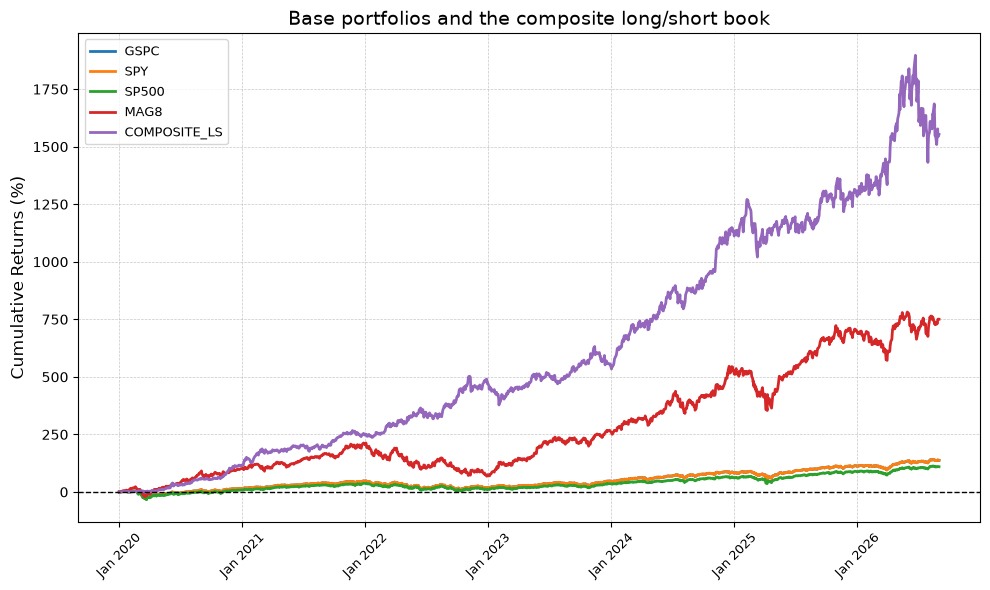

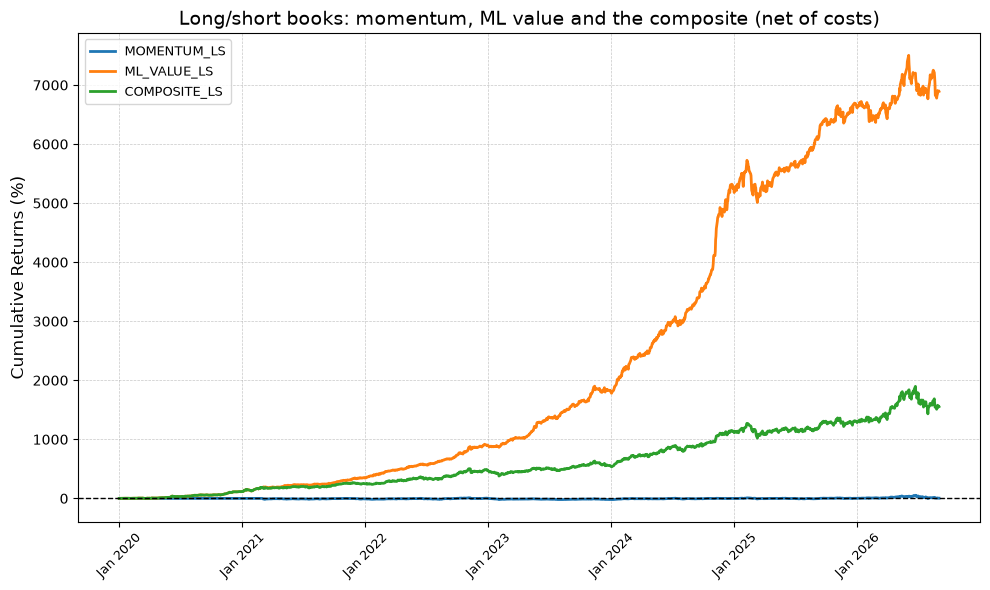

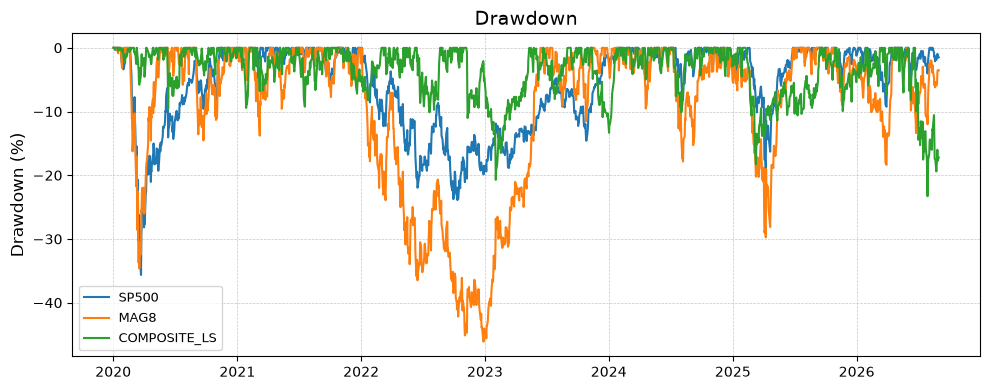

,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,beta,correlation,tracking_error,annual_turnover
GSPC,1.3760,0.1393,0.2031,0.7443,1.0506,-0.3392,0.4107,0.5431,1672,NaN,NaN,NaN,NaN
MAG8,7.5052,0.3808,0.3166,1.1781,1.7132,-0.4612,0.8257,0.5556,1672,1.3555,0.8694,0.1723,NaN
SP500,1.0984,0.1182,0.2014,0.6557,0.9230,-0.3564,0.3316,0.5431,1672,0.9872,0.9953,0.0196,NaN
SPY,1.3791,0.1395,0.2020,0.7480,1.0558,-0.3410,0.4092,0.5484,1672,0.9924,0.9977,0.0139,NaN
MOMENTUM_LS,0.0321,0.0048,0.2453,0.1428,0.1909,-0.3603,0.0132,0.4456,1674,NaN,NaN,NaN,5.4854
ML_VALUE_LS,68.9178,0.8953,0.1608,4.0623,7.1442,-0.1223,7.3178,0.6135,1674,NaN,NaN,NaN,2.6928
COMPOSITE_LS,15.5337,0.5255,0.2305,1.9490,2.8614,-0.2329,2.2563,0.5812,1674,NaN,NaN,NaN,5.4087


In [10]:
all_returns = pd.concat([base.returns, long_short.returns], axis=1).dropna(how="all")
display(plot_cumulative_returns(all_returns[["GSPC", "SPY", "SP500", "MAG8", "COMPOSITE_LS"]], title="Base portfolios and the composite long/short book"))
display(plot_cumulative_returns(long_short.returns, title="Long/short books: momentum, ML value and the composite (net of costs)"))
display(plot_drawdowns(all_returns[["SP500", "MAG8", "COMPOSITE_LS"]]))

summary = pd.concat([base.summary(benchmark="GSPC"), long_short.summary()]).round(4)
display(summary)

## 4.9 Audit: no forward-looking fundamentals

Re-derive, for each quarter end, the latest `effective_date` per (security, ratio) in the database and confirm the
provider never returned anything newer. Must print **0**.

In [11]:
stored = database.read_security_fundamentals(session, engine, metric_type=None)
stored = stored[(stored["source_vendor"] == SOURCE_VENDOR) & stored["security_id"].isin(universe_ids)]
audit_provider = StaticFundamentalsProvider(session, engine, source_vendor=SOURCE_VENDOR)   # lag 0: strict effective_date check
print("future-dated ratios visible to the scorer (must be 0):", check_point_in_time(audit_provider, symbols, START_DATE, END_DATE, stored))

session.close()
connection.close()

future-dated ratios visible to the scorer (must be 0): 0


## 4.10 Summary and next experiments

* `MOMENTUM_LS`, `ML_VALUE_LS` and `COMPOSITE_LS` are dollar-neutral, so compare them on Sharpe, drawdown and turnover
  rather than total return; the base portfolios are long-only market exposure.
* The IC table in 4.6 is the fastest diagnostic: if a signal's mean IC is not clearly positive on this universe, no
  amount of portfolio construction will rescue it.
* Things to try next (details in `docs/STRATEGY_IMPROVEMENTS.md`): sector-neutral z-scores (`neutralize`),
  volatility-scaled momentum (`MomentumFactor(vol_scale=True)`), a transparent `ValueFactor` alongside the ML one,
  rank-based blending (`method="rank"`), shallower trees / walk-forward retraining for the ML models, position caps
  and a holding-period buffer to cut turnover.